In [ ]:
!pip install transformers datasets scikit-learn torch matplotlib seaborn umap-learn -q

In [14]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoTokenizer, AutoModel
from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from scipy.stats import pearsonr
import seaborn as sns
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

# 1. Загрузка

In [15]:
model_name = "bert-large-uncased"
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, output_hidden_states=True).to(device).eval()

dataset = load_dataset("dair-ai/emotion")
emotion_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]

train_data = dataset["train"].shuffle(seed=42).select(range(2000))
test_data = dataset["test"].shuffle(seed=42).select(range(800))

print(f"Device: {device}")
print(f"Layers: {model.config.num_hidden_layers}")

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-large-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Device: cuda
Layers: 24


# 2. Извлечение

In [16]:
def extract_embeddings(texts):
    num_layers = model.config.num_hidden_layers + 1
    all_layers = {i: [] for i in range(num_layers)}
    
    for i in tqdm(range(0, len(texts), 16), desc="Extracting"):
        batch = texts[i:i+16]
        inputs = tokenizer(batch, return_tensors="pt", truncation=True, 
                          max_length=128, padding=True).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            
        for layer_idx, state in enumerate(outputs.hidden_states):
            cls_emb = state[:, 0, :].cpu().numpy()
            all_layers[layer_idx].append(cls_emb)
            
    return {k: np.vstack(v) for k, v in all_layers.items()}

X_train = extract_embeddings(train_data["text"])
X_test = extract_embeddings(test_data["text"])
y_train, y_test = np.array(train_data["label"]), np.array(test_data["label"])

Extracting:   0%|          | 0/125 [00:00<?, ?it/s]

Extracting:   0%|          | 0/50 [00:00<?, ?it/s]

# 3. Probing + separability

In [17]:
results = {"layer": [], "train_acc": [], "test_acc": [], "f1_macro": [], "separability": []}

def compute_separability(X, y):
    centroids = np.array([X[y == i].mean(axis=0) for i in range(6)])
    dists = [np.linalg.norm(centroids[i] - centroids[j]) 
             for i in range(6) for j in range(i+1, 6)]
    return np.mean(dists)

for layer in range(len(X_train)):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train[layer], y_train)
    
    train_preds = clf.predict(X_train[layer])
    test_preds = clf.predict(X_test[layer])
    
    results["layer"].append(layer)
    results["train_acc"].append(accuracy_score(y_train, train_preds))
    results["test_acc"].append(accuracy_score(y_test, test_preds))
    results["f1_macro"].append(f1_score(y_test, test_preds, average="macro"))
    results["separability"].append(compute_separability(X_test[layer], y_test))

df = pd.DataFrame(results)
df["overfit"] = df["train_acc"] - df["test_acc"]
df["group"] = pd.cut(df["layer"], bins=[-1, 6, 17, 25], 
                     labels=["Early (0-6)", "Mid (7-17)", "Late (18-24)"])

# 4. Результаты

In [21]:
print("\n" + "_"*80)
print("Результаты по группам")
print("\n" + "_"*80)
print(df.groupby("group")["test_acc"].agg(["mean", "std", "max"]).round(4))

print("\n" + "_"*80)
print("Топ-3 СЛОЯ")
print("\n" + "_"*80)
print(df.nlargest(3, "test_acc")[["layer", "test_acc", "f1_macro", "separability"]].to_string(index=False))


________________________________________________________________________________
Результаты по группам

________________________________________________________________________________
                mean     std     max
group                               
Early (0-6)   0.5438  0.0893  0.6225
Mid (7-17)    0.5799  0.0193  0.6050
Late (18-24)  0.5293  0.0171  0.5512

________________________________________________________________________________
Топ-3 СЛОЯ

________________________________________________________________________________
 layer  test_acc  f1_macro  separability
     6    0.6225  0.493104      0.661614
     5    0.6100  0.449530      0.429833
     8    0.6050  0.497039      1.119471


# 5. Визуализация

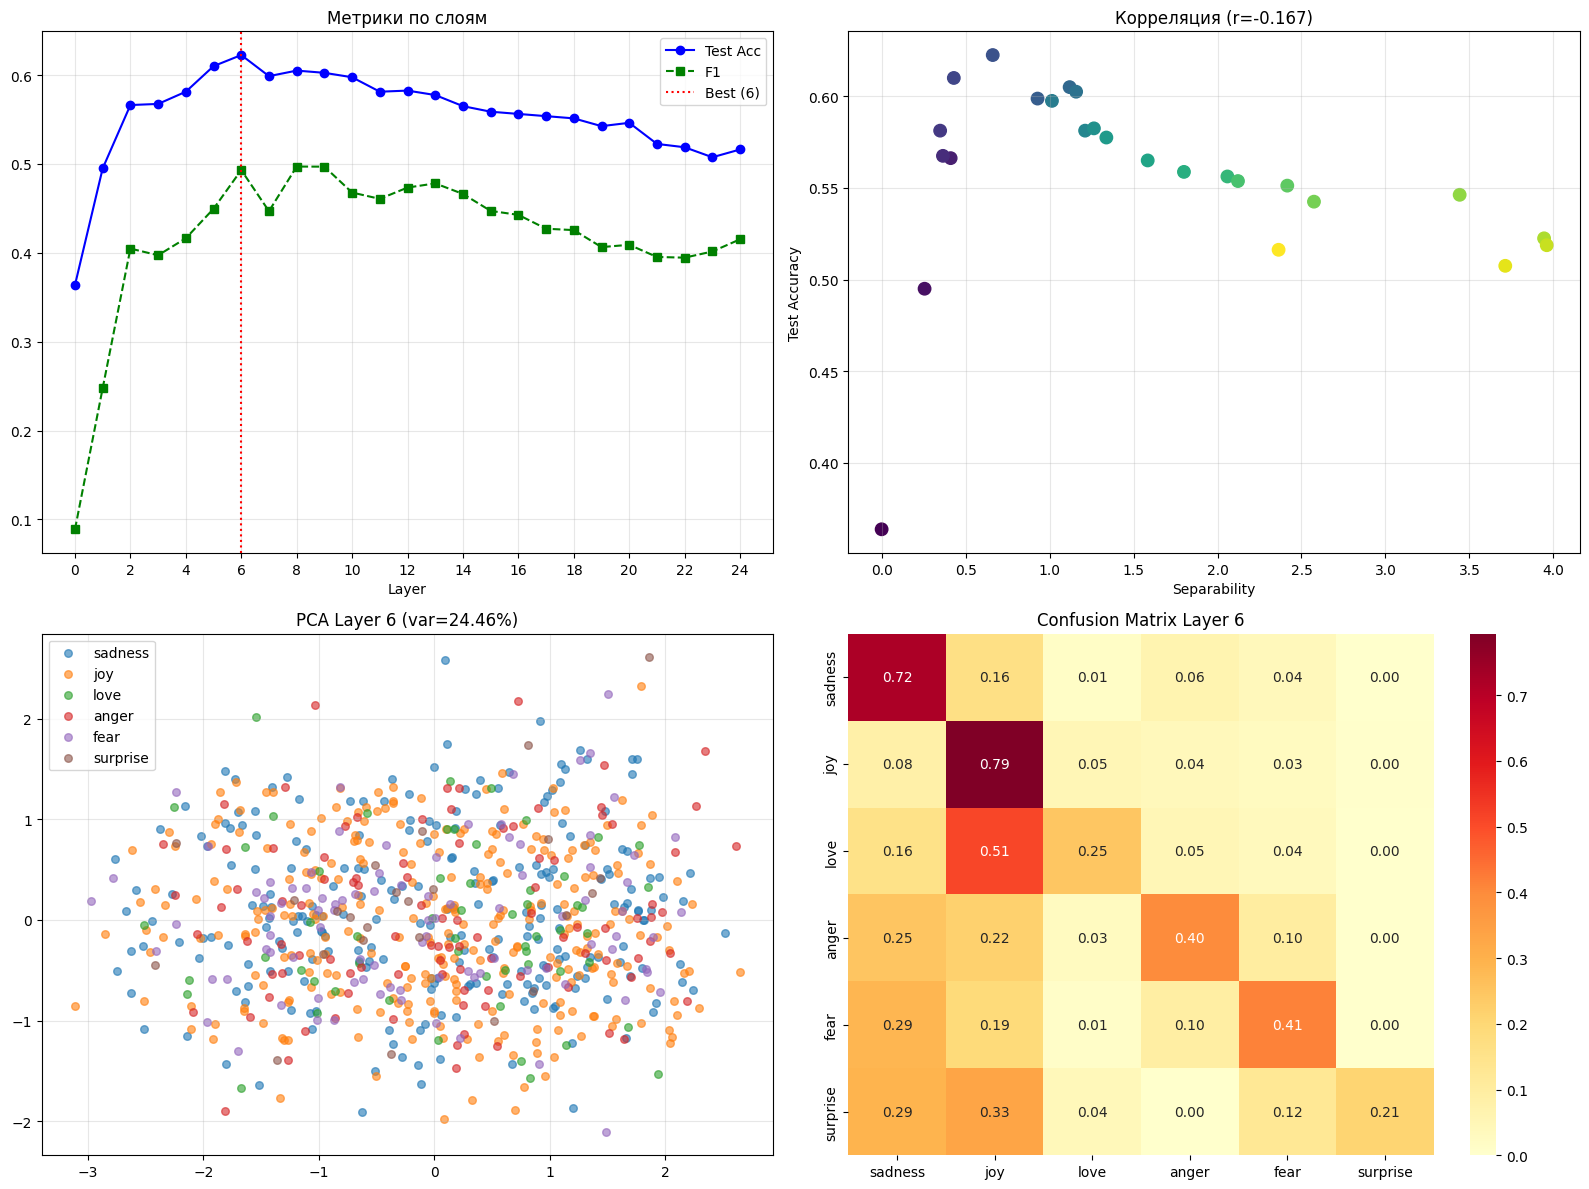

In [19]:
best = int(df.nlargest(1, "test_acc").iloc[0]["layer"])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Метрики
axes[0,0].plot(df["layer"], df["test_acc"], marker="o", label="Test Acc", color="b")
axes[0,0].plot(df["layer"], df["f1_macro"], marker="s", linestyle="--", label="F1", color="g")
axes[0,0].axvline(x=best, color="r", linestyle=":", label=f"Best ({best})")
axes[0,0].set_title("Метрики по слоям")
axes[0,0].set_xlabel("Layer")
axes[0,0].set_xticks(range(0, 25, 2))
axes[0,0].grid(alpha=0.3)
axes[0,0].legend()

# Separability
axes[0,1].scatter(df["separability"], df["test_acc"], c=df["layer"], cmap="viridis", s=80)
axes[0,1].set_xlabel("Separability")
axes[0,1].set_ylabel("Test Accuracy")
axes[0,1].set_title(f"Корреляция (r={pearsonr(df['separability'], df['test_acc'])[0]:.3f})")
axes[0,1].grid(alpha=0.3)

# PCA лучшего слоя
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_test[best])
for idx, emotion in enumerate(emotion_names):
    mask = y_test == idx
    axes[1,0].scatter(X_pca[mask, 0], X_pca[mask, 1], label=emotion, alpha=0.6, s=30)
axes[1,0].set_title(f"PCA Layer {best} (var={pca.explained_variance_ratio_.sum():.2%})")
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Confusion matrix
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train[best], y_train)
preds = clf.predict(X_test[best])
cm = confusion_matrix(y_test, preds)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd", 
           xticklabels=emotion_names, yticklabels=emotion_names, ax=axes[1,1])
axes[1,1].set_title(f"Confusion Matrix Layer {best}")

plt.tight_layout()
plt.show()

# 6. Выводы

In [22]:
print("\n" + "_"*80)
print("Выводы")
print("_"*80)
print(f"\n1. Лучший слой: {best} (accuracy={df.iloc[best]['test_acc']:.4f})")
print(f"2. Улучшение от embedding слоя: {df.iloc[best]['test_acc'] - df.iloc[0]['test_acc']:.4f}")
print(f"3. Корреляция separability-accuracy: {pearsonr(df['separability'], df['test_acc'])[0]:.3f}")


________________________________________________________________________________
Выводы
________________________________________________________________________________

1. Лучший слой: 6 (accuracy=0.6225)
2. Улучшение от embedding слоя: 0.2588
3. Корреляция separability-accuracy: -0.167


По результатам экспериментов видно, что для классификации эмоций самые полезные признаки лежат вовсе не в конце модели. Максимальное качество выдал 6 слой (accuracy 0.62).

Если смотреть по группам, то нулевой слой работает хуже всего, так как там еще нет контекста. Затем качество быстро растет. Средние слои (7-17) в целом оказались самыми стабильными. А вот ближе к концу (18-24 слои) метрики начинают падать - скорее всего, сеть там слишком сильно затачивается под свою базовую задачу претрейна (MLM) и теряет универсальную семантику.

По матрице ошибок 6 слоя хорошо видно, что модель уверенно ловит базовые "joy" и "sadness", но путается в смежных эмоциях - например, часто принимает ""love"" за тот же ""joy"". 

Также интересный момент получился с разделимостью (separability). График показал отрицательную корреляцию: слои, которые раскидывают кластеры эмоций максимально далеко друг от друга, работают хуже. Оказалось, что просто раздвинуть классы - не значит сделать их легко разделимыми для логистической регрессии. Баланс достигается как раз где-то в начале-середине сети.

Главный вывод: брать эмбеддинги из самого последнего слоя LLM для классификации текстов - не лучшее решение. Лучше вытаскивать признаки из 6-8 слоев. Это и метрики поднимет, и время на инференс сэкономит.